In [1]:
import os
import json
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

import matplotlib.pyplot as plt

DATASET_ROOT = Path("..") / "smartvision_dataset"
CLASSIFICATION_DIR = DATASET_ROOT / "classification"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [3]:
train_dataset = datasets.ImageFolder(root=CLASSIFICATION_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=CLASSIFICATION_DIR / "val", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=CLASSIFICATION_DIR / "test", transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 25 | Train: 1750 | Val: 375 | Test: 375


In [4]:
import torch.nn as nn

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze convolutional base
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier head for 25 classes
vgg16.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)

vgg16 = vgg16.to(device)
print(vgg16.classifier)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=25, bias=True)
  )
)


In [5]:
criterion = nn.CrossEntropyLoss()

# Only the new classifier head has requires_grad=True, so only those params get optimized
optimizer = optim.Adam(vgg16.classifier[6].parameters(), lr=0.001)

# Reduce LR if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


In [16]:
import time
import copy

EPOCHS = 10
best_val_acc = 0.0
best_model_weights = copy.deepcopy(vgg16.state_dict())
patience = 3
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    # ---- Training phase ----
    vgg16.train()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    # ---- Validation phase ----
    vgg16.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    # Save best model, track early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(vgg16.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

vgg16.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/10 (101.0s) - train_loss: 2.3297, train_acc: 0.3463, val_loss: 1.8856, val_acc: 0.4773
Epoch 2/10 (99.7s) - train_loss: 1.3765, train_acc: 0.6131, val_loss: 1.6825, val_acc: 0.5387
Epoch 3/10 (98.9s) - train_loss: 1.0794, train_acc: 0.7057, val_loss: 1.6272, val_acc: 0.5387
Epoch 4/10 (98.0s) - train_loss: 0.9371, train_acc: 0.7417, val_loss: 1.5879, val_acc: 0.5653
Epoch 5/10 (98.1s) - train_loss: 0.8421, train_acc: 0.7697, val_loss: 1.5751, val_acc: 0.5707
Epoch 6/10 (97.8s) - train_loss: 0.7695, train_acc: 0.7880, val_loss: 1.5671, val_acc: 0.5360
Epoch 7/10 (97.9s) - train_loss: 0.7299, train_acc: 0.7897, val_loss: 1.5567, val_acc: 0.5707
Epoch 8/10 (98.2s) - train_loss: 0.6837, train_acc: 0.8137, val_loss: 1.5595, val_acc: 0.5707
Early stopping triggered at epoch 8

Best validation accuracy: 0.5707


In [29]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg16.features.parameters():
    param.requires_grad = False

# Simpler head: dropout + single linear layer (fewer params, less overfitting risk)
vgg16.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(4096, NUM_CLASSES)
)

vgg16 = vgg16.to(device)
print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=25, bias=True)
  )
)


In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier[6].parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


In [31]:
import time
import copy

EPOCHS = 10
best_val_acc = 0.0
best_model_weights = copy.deepcopy(vgg16.state_dict())
patience = 5
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    # ---- Training phase ----
    vgg16.train()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    # ---- Validation phase ----
    vgg16.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    # Save best model, track early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(vgg16.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

vgg16.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/10 (101.7s) - train_loss: 2.4028, train_acc: 0.3229, val_loss: 1.5113, val_acc: 0.6133
Epoch 2/10 (99.9s) - train_loss: 1.4283, train_acc: 0.5897, val_loss: 1.2119, val_acc: 0.6853
Epoch 3/10 (98.6s) - train_loss: 1.1961, train_acc: 0.6486, val_loss: 1.0813, val_acc: 0.7253
Epoch 4/10 (99.0s) - train_loss: 1.0437, train_acc: 0.6931, val_loss: 0.9973, val_acc: 0.7360
Epoch 5/10 (99.2s) - train_loss: 0.8953, train_acc: 0.7349, val_loss: 0.9550, val_acc: 0.7440
Epoch 6/10 (98.2s) - train_loss: 0.8335, train_acc: 0.7474, val_loss: 0.9046, val_acc: 0.7547
Epoch 7/10 (98.8s) - train_loss: 0.7800, train_acc: 0.7743, val_loss: 0.8829, val_acc: 0.7787
Epoch 8/10 (98.9s) - train_loss: 0.7427, train_acc: 0.7800, val_loss: 0.8587, val_acc: 0.7707
Epoch 9/10 (98.9s) - train_loss: 0.7072, train_acc: 0.7960, val_loss: 0.8443, val_acc: 0.7813
Epoch 10/10 (100.1s) - train_loss: 0.6487, train_acc: 0.8040, val_loss: 0.8211, val_acc: 0.7787

Best validation accuracy: 0.7813


In [17]:
with open(DATASET_ROOT / "dataset_metadata.json", "r") as f:
    metadata = json.load(f)

print(type(metadata))
if isinstance(metadata, dict):
    print(list(metadata.keys()))
else:
    print(metadata[:2] if isinstance(metadata, list) else metadata)

<class 'dict'>
['total_images', 'classes', 'splits', 'classification', 'detection', 'dataset_path']


In [18]:
print("classification metadata sample:")
print(json.dumps(metadata["classification"], indent=2)[:1000])

print("\ndetection metadata sample:")
print(json.dumps(metadata["detection"], indent=2)[:1000])

classification metadata sample:
{
  "train": 1750,
  "val": 375,
  "test": 375
}

detection metadata sample:
{
  "images": 2125,
  "annotations": 2125,
  "objects": 21578
}


In [20]:
from pathlib import Path
import json

DATASET_ROOT = Path("..") / "smartvision_dataset"
DETECTION_DIR = DATASET_ROOT / "detection"
DETECTION_IMAGES = DETECTION_DIR / "images"
DETECTION_LABELS = DETECTION_DIR / "labels"

import yaml
with open(DETECTION_DIR / "data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml["names"]

In [21]:
from collections import defaultdict

class_counts = defaultdict(int)

for label_file in DETECTION_LABELS.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f.readlines():
            class_id = int(line.strip().split()[0])
            class_counts[class_id] += 1

for idx in sorted(class_counts.keys()):
    print(f"{CLASS_NAMES[idx]}: {class_counts[idx]}")

person: 6314
bicycle: 653
car: 2147
motorcycle: 484
airplane: 301
bus: 513
truck: 566
traffic light: 877
stop sign: 104
bench: 347
bird: 862
cat: 162
dog: 359
horse: 400
cow: 374
elephant: 435
bottle: 1242
cup: 1265
bowl: 633
pizza: 276
cake: 828
chair: 1532
couch: 265
potted plant: 516
bed: 123


In [23]:
import cv2

# Build a list of all (image_path, class_id, bbox) instances, grouped by class
instances_by_class = defaultdict(list)

for label_file in DETECTION_LABELS.glob("*.txt"):
    image_stem = label_file.stem
    # Find matching image
    image_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = DETECTION_IMAGES / (image_stem + ext)
        if candidate.exists():
            image_path = candidate
            break
    if image_path is None:
        continue

    with open(label_file, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center, y_center, w, h = map(float, parts[1:5])
            instances_by_class[class_id].append((image_path, x_center, y_center, w, h))

for idx in sorted(instances_by_class.keys()):
    print(f"{CLASS_NAMES[idx]}: {len(instances_by_class[idx])} available")

person: 6314 available
bicycle: 653 available
car: 2147 available
motorcycle: 484 available
airplane: 301 available
bus: 513 available
truck: 566 available
traffic light: 877 available
stop sign: 104 available
bench: 347 available
bird: 862 available
cat: 162 available
dog: 359 available
horse: 400 available
cow: 374 available
elephant: 435 available
bottle: 1242 available
cup: 1265 available
bowl: 633 available
pizza: 276 available
cake: 828 available
chair: 1532 available
couch: 265 available
potted plant: 516 available
bed: 123 available


In [24]:
import random

random.seed(42)
IMAGES_PER_CLASS = 100

NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"

for split in ["train", "val", "test"]:
    for class_name in CLASS_NAMES.values():
        (NEW_CLASSIFICATION_DIR / split / class_name).mkdir(parents=True, exist_ok=True)

def crop_and_resize(image_path, x_center, y_center, w, h, size=224):
    img = cv2.imread(str(image_path))
    img_h, img_w = img.shape[:2]

    x1 = max(0, int((x_center - w/2) * img_w))
    y1 = max(0, int((y_center - h/2) * img_h))
    x2 = min(img_w, int((x_center + w/2) * img_w))
    y2 = min(img_h, int((y_center + h/2) * img_h))

    if x2 <= x1 or y2 <= y1:
        return None

    crop = img[y1:y2, x1:x2]
    # Direct resize (squash) to fill the frame — no padding
    resized = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return resized

summary = {}

for class_id, instances in instances_by_class.items():
    class_name = CLASS_NAMES[class_id]
    random.shuffle(instances)
    selected = instances[:IMAGES_PER_CLASS]

    n_train = int(0.70 * len(selected))
    n_val = int(0.15 * len(selected))
    splits_data = {
        "train": selected[:n_train],
        "val": selected[n_train:n_train + n_val],
        "test": selected[n_train + n_val:]
    }

    counts = {}
    for split, split_instances in splits_data.items():
        saved = 0
        for i, (image_path, xc, yc, w, h) in enumerate(split_instances):
            resized = crop_and_resize(image_path, xc, yc, w, h)
            if resized is None:
                continue
            out_path = NEW_CLASSIFICATION_DIR / split / class_name / f"{class_name}_{split}_{i:04d}.jpg"
            cv2.imwrite(str(out_path), resized)
            saved += 1
        counts[split] = saved

    summary[class_name] = counts
    print(f"{class_name}: {counts}")

print("\nDone.")

person: {'train': 70, 'val': 15, 'test': 15}
horse: {'train': 70, 'val': 15, 'test': 15}
potted plant: {'train': 70, 'val': 15, 'test': 15}
elephant: {'train': 70, 'val': 15, 'test': 15}
dog: {'train': 70, 'val': 15, 'test': 15}
bicycle: {'train': 70, 'val': 15, 'test': 15}
motorcycle: {'train': 70, 'val': 15, 'test': 15}
bench: {'train': 70, 'val': 15, 'test': 15}
chair: {'train': 70, 'val': 15, 'test': 15}
pizza: {'train': 70, 'val': 15, 'test': 15}
cup: {'train': 70, 'val': 15, 'test': 15}
cake: {'train': 70, 'val': 15, 'test': 15}
car: {'train': 70, 'val': 15, 'test': 15}
stop sign: {'train': 70, 'val': 15, 'test': 15}
bottle: {'train': 70, 'val': 15, 'test': 15}
couch: {'train': 70, 'val': 15, 'test': 15}
traffic light: {'train': 70, 'val': 15, 'test': 15}
truck: {'train': 70, 'val': 15, 'test': 15}
bus: {'train': 70, 'val': 15, 'test': 15}
bed: {'train': 70, 'val': 15, 'test': 15}
cow: {'train': 70, 'val': 15, 'test': 15}
bowl: {'train': 70, 'val': 15, 'test': 15}
airplane: {'tra

In [26]:
from PIL import Image

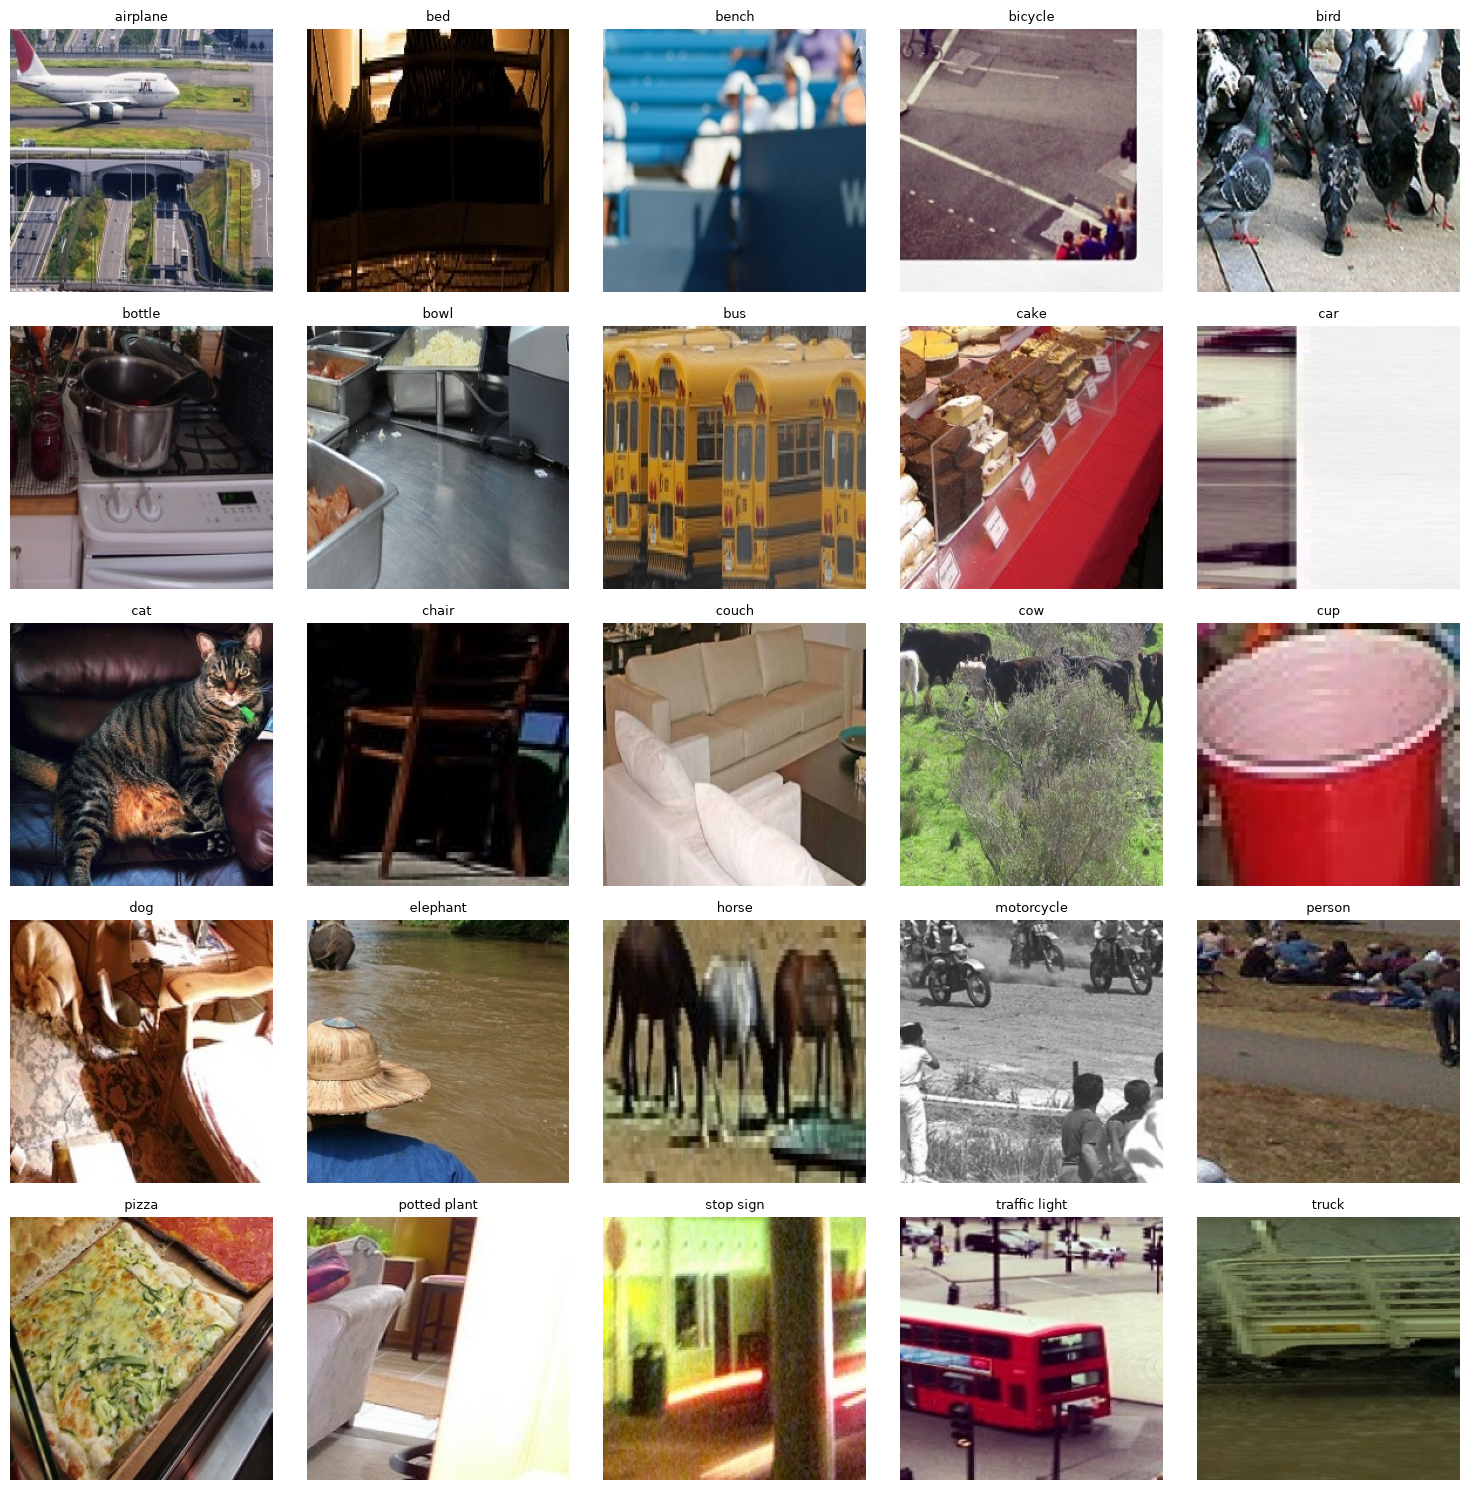

In [27]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for ax, class_name in zip(axes.flatten(), sorted(CLASS_NAMES.values())):
    class_folder = NEW_CLASSIFICATION_DIR / "train" / class_name
    sample_img = random.choice(list(class_folder.glob("*.jpg")))
    img = Image.open(sample_img)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/eda_plots/classification_v2_samples_grid.png")
plt.show()

In [28]:
NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"

train_dataset = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "val", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "test", transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 25 | Train: 1750 | Val: 375 | Test: 375


In [32]:
EPOCHS = 8  # additional epochs on top of the current model state

for epoch in range(EPOCHS):
    start_time = time.time()

    vgg16.train()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    vgg16.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(vgg16.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

vgg16.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy so far: {best_val_acc:.4f}")

Epoch 1/8 (99.0s) - train_loss: 0.6746, train_acc: 0.8034, val_loss: 0.8253, val_acc: 0.7787
Epoch 2/8 (98.9s) - train_loss: 0.6283, train_acc: 0.8046, val_loss: 0.8157, val_acc: 0.7787
Epoch 3/8 (98.7s) - train_loss: 0.6102, train_acc: 0.8103, val_loss: 0.8103, val_acc: 0.7840
Epoch 4/8 (99.0s) - train_loss: 0.5698, train_acc: 0.8286, val_loss: 0.7872, val_acc: 0.7947
Epoch 5/8 (99.2s) - train_loss: 0.5668, train_acc: 0.8280, val_loss: 0.7838, val_acc: 0.7920
Epoch 6/8 (99.2s) - train_loss: 0.5292, train_acc: 0.8326, val_loss: 0.7820, val_acc: 0.8000
Epoch 7/8 (101.3s) - train_loss: 0.4962, train_acc: 0.8440, val_loss: 0.7752, val_acc: 0.8027
Epoch 8/8 (99.3s) - train_loss: 0.4990, train_acc: 0.8457, val_loss: 0.7732, val_acc: 0.8107

Best validation accuracy so far: 0.8107


In [34]:
import sklearn.metrics as metrics

# Save the trained model weights
os.makedirs("../models", exist_ok=True)
torch.save(vgg16.state_dict(), "../models/vgg16_best.pth")
print("Model saved to ../models/vgg16_best.pth")

# Evaluate on test set
vgg16.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = metrics.accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(metrics.classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Model saved to ../models/vgg16_best.pth

Test Accuracy: 0.7653

Classification Report:
               precision    recall  f1-score   support

     airplane       0.94      1.00      0.97        15
          bed       0.67      0.67      0.67        15
        bench       0.75      0.60      0.67        15
      bicycle       0.93      0.93      0.93        15
         bird       0.93      0.93      0.93        15
       bottle       0.80      0.53      0.64        15
         bowl       0.73      0.73      0.73        15
          bus       0.68      0.87      0.76        15
         cake       0.86      0.80      0.83        15
          car       0.38      0.53      0.44        15
          cat       1.00      0.93      0.97        15
        chair       0.80      0.80      0.80        15
        couch       0.63      0.80      0.71        15
          cow       0.71      1.00      0.83        15
          cup       0.58      0.73      0.65        15
          dog       0.88      1.

In [36]:
os.makedirs("../results/confusion_matrices", exist_ok=True)

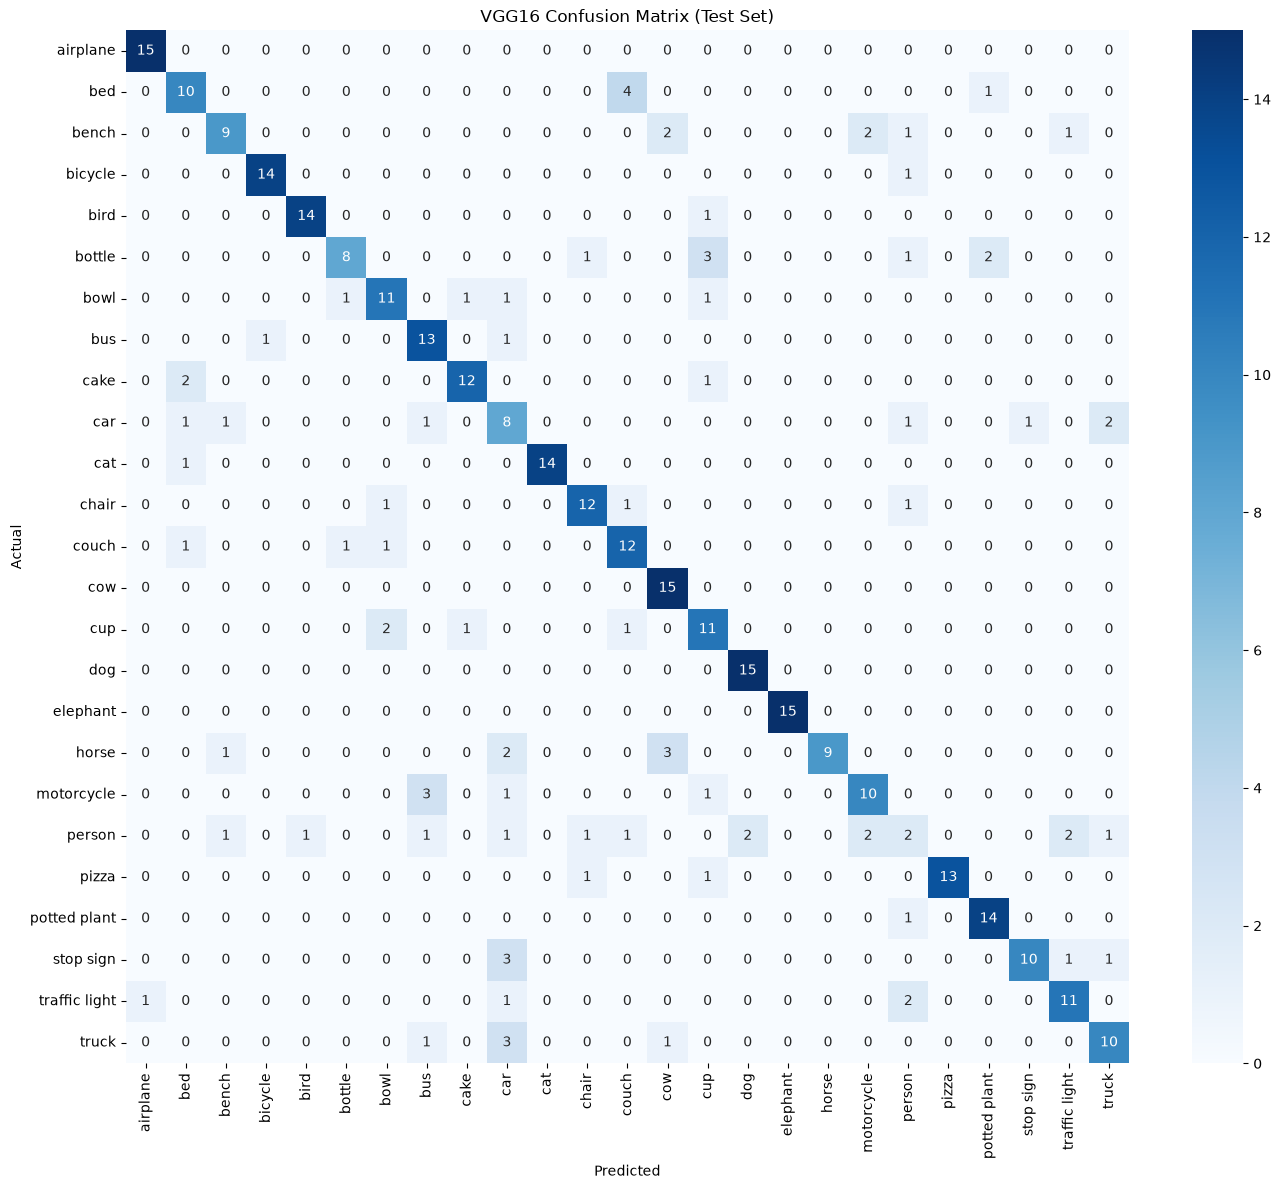

In [37]:
import seaborn as sns

cm = metrics.confusion_matrix(all_labels, all_preds)
class_names_sorted = test_dataset.classes

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_sorted, yticklabels=class_names_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix (Test Set)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/confusion_matrices/vgg16_confusion_matrix.png")
plt.show()